In [1]:
import cv2 
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [18]:
image = cv2.imread('Screenshot_2.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

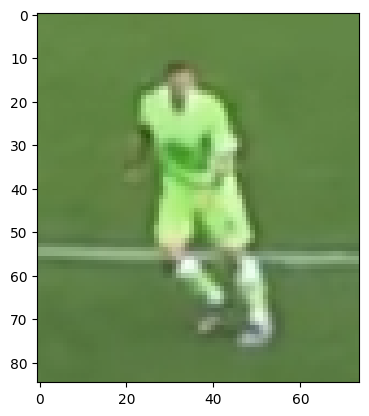

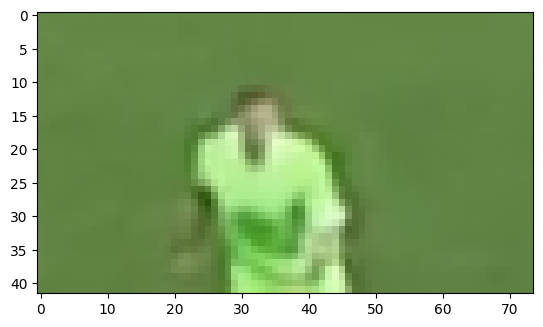

In [20]:
plt.imshow(image)
plt.show()

top_half_image=  image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

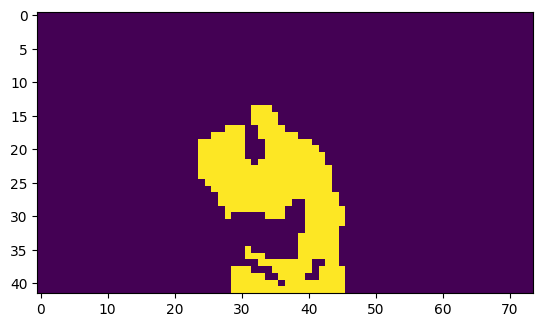

In [21]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [22]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [23]:
player_cluster = 1-non_player_cluster
print(player_cluster)


1


In [24]:
kmeans.cluster_centers_[player_cluster]


array([175.01190476, 223.875     , 141.33630952])

# KMeans From Scratch


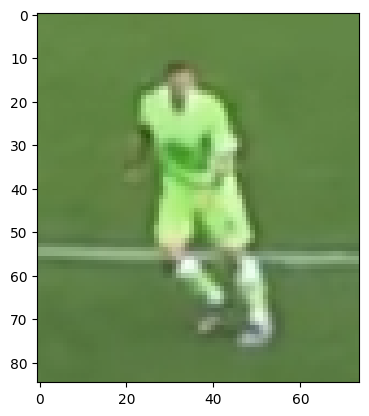

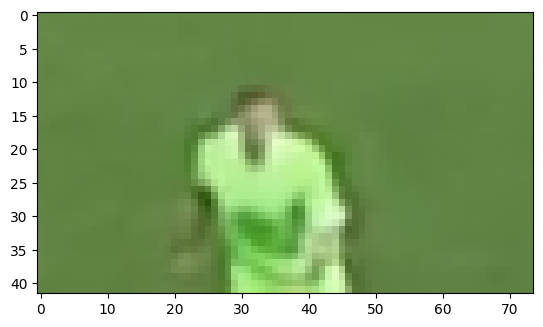

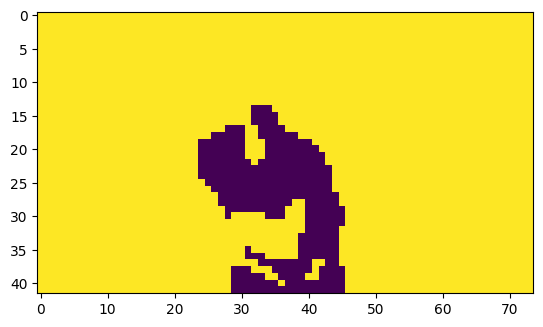

Non-player cluster: 1
Player cluster: 0
Player cluster RGB color: [175.01190476 223.875      141.33630952]


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load image
# -------------------------------
image = cv2.imread('Screenshot_2.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

# Take top half of image
top_half_image = image[0:int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# -------------------------------
# Reshape image into 2D array of pixels
# -------------------------------
pixels = top_half_image.reshape(-1, 3).astype(float)  # shape (num_pixels, 3)

# -------------------------------
# K-Means from scratch
# -------------------------------
def kmeans_numpy(X, k=2, max_iters=100, tol=1e-4):
    # Initialize cluster centers randomly
    np.random.seed(0)
    centers = X[np.random.choice(len(X), k, replace=False)]
    
    for i in range(max_iters):
        # Step 1: Assign clusters
        distances = np.linalg.norm(X[:, None] - centers[None, :], axis=2)  # shape (num_pixels, k)
        labels = np.argmin(distances, axis=1)  # closest center
        
        # Step 2: Update cluster centers
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        # Step 3: Check for convergence
        if np.all(np.linalg.norm(new_centers - centers, axis=1) < tol):
            break
        centers = new_centers
    
    return labels, centers

# Run K-Means
labels, centers = kmeans_numpy(pixels, k=2)

# -------------------------------
# Reshape labels to image
# -------------------------------
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])
plt.imshow(clustered_image)
plt.show()

# -------------------------------
# Determine non-player cluster
# -------------------------------
corner_clusters = [
    clustered_image[0, 0], 
    clustered_image[0, -1], 
    clustered_image[-1, 0], 
    clustered_image[-1, -1]
]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print("Non-player cluster:", non_player_cluster)

player_cluster = 1 - non_player_cluster
print("Player cluster:", player_cluster)

# Get player cluster color (mean RGB)
player_color = centers[player_cluster]
print("Player cluster RGB color:", player_color)